# Executive Exploratory Data Analysis

Timothy Kurnia Hardiman (thardiman3@gatech.edu) - Team23

## 1. Executive Summary

Exploratory data analysis and some feature engineering have been completed. For the polymarket dataset, I focused on the Bitcoin markets and categorizing whether each trade is bullish/bearish/neutral based on the question, token, and transaction type. However, accumulation signals so far has not straightforward and require further development.

## 2. Data Retrieval

In [95]:
# Dependencies

from contextlib import contextmanager
from datetime import datetime
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import polars as pl
import psutil
import seaborn as sns
import numpy as np
import pandas as pd

import eda_starter as eda

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

from xgboost import XGBRegressor
import shap

In [20]:
import importlib
importlib.reload(eda)

<module 'eda_starter' from 'C:\\Users\\timot\\OneDrive\\Learn\\GT OMSA\\Practicum\\eda\\eda_starter.py'>

In [100]:
# Load btc data
btc_df = eda.load_bitcoin_data(eda.COINMETRICS_PATH)
# Load polymarket data
poly_data = eda.load_polymarket_data(eda.POLYMARKET_DIR)

Loading Bitcoin data from C:\Users\timot\OneDrive\Learn\GT OMSA\Practicum\data\Coin Metrics\coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 619.41 MB
[Memory] After loading Bitcoin data: 644.14 MB (Δ 24.73 MB)
Successfully loaded 6221 rows.
Loading Polymarket data from C:\Users\timot\OneDrive\Learn\GT OMSA\Practicum\data\Polymarket...
[Memory] Before loading Polymarket data: 644.20 MB
Loaded 78321 markets.
Loaded 2143181 odds history records.
Loaded 78321 summary records.
Loaded 156636 tokens records.
Loaded 27013724 trades records.
Loaded 44033 events records.
[Memory] After loading Polymarket data: 1.63 GB (Δ 1.01 GB)


## 3. General Dataset Overview

### 3.1 Bitcoin data overview

 Some columns such as ReferenceRateUSD, ReferenceRateEUR, ReferenceRateETH, ReferenceRate, and CapMrktEstUSD are mostly empty

In [102]:
btc_df["time"].min()

datetime.datetime(2009, 1, 3, 0, 0)

In [3]:
desc = btc_df.describe().to_pandas()
row = desc.iloc[1, 2:] / btc_df.shape[0]
row.sort_values(ascending=False,inplace=True)
row[:8]

ReferenceRateUSD    0.998875
ReferenceRateEUR    0.998875
ReferenceRateETH    0.998875
ReferenceRate       0.998875
CapMrktEstUSD       0.614531
ROI1yr              0.149011
ROI30d              0.095162
IssTotUSD           0.090339
Name: 1, dtype: object

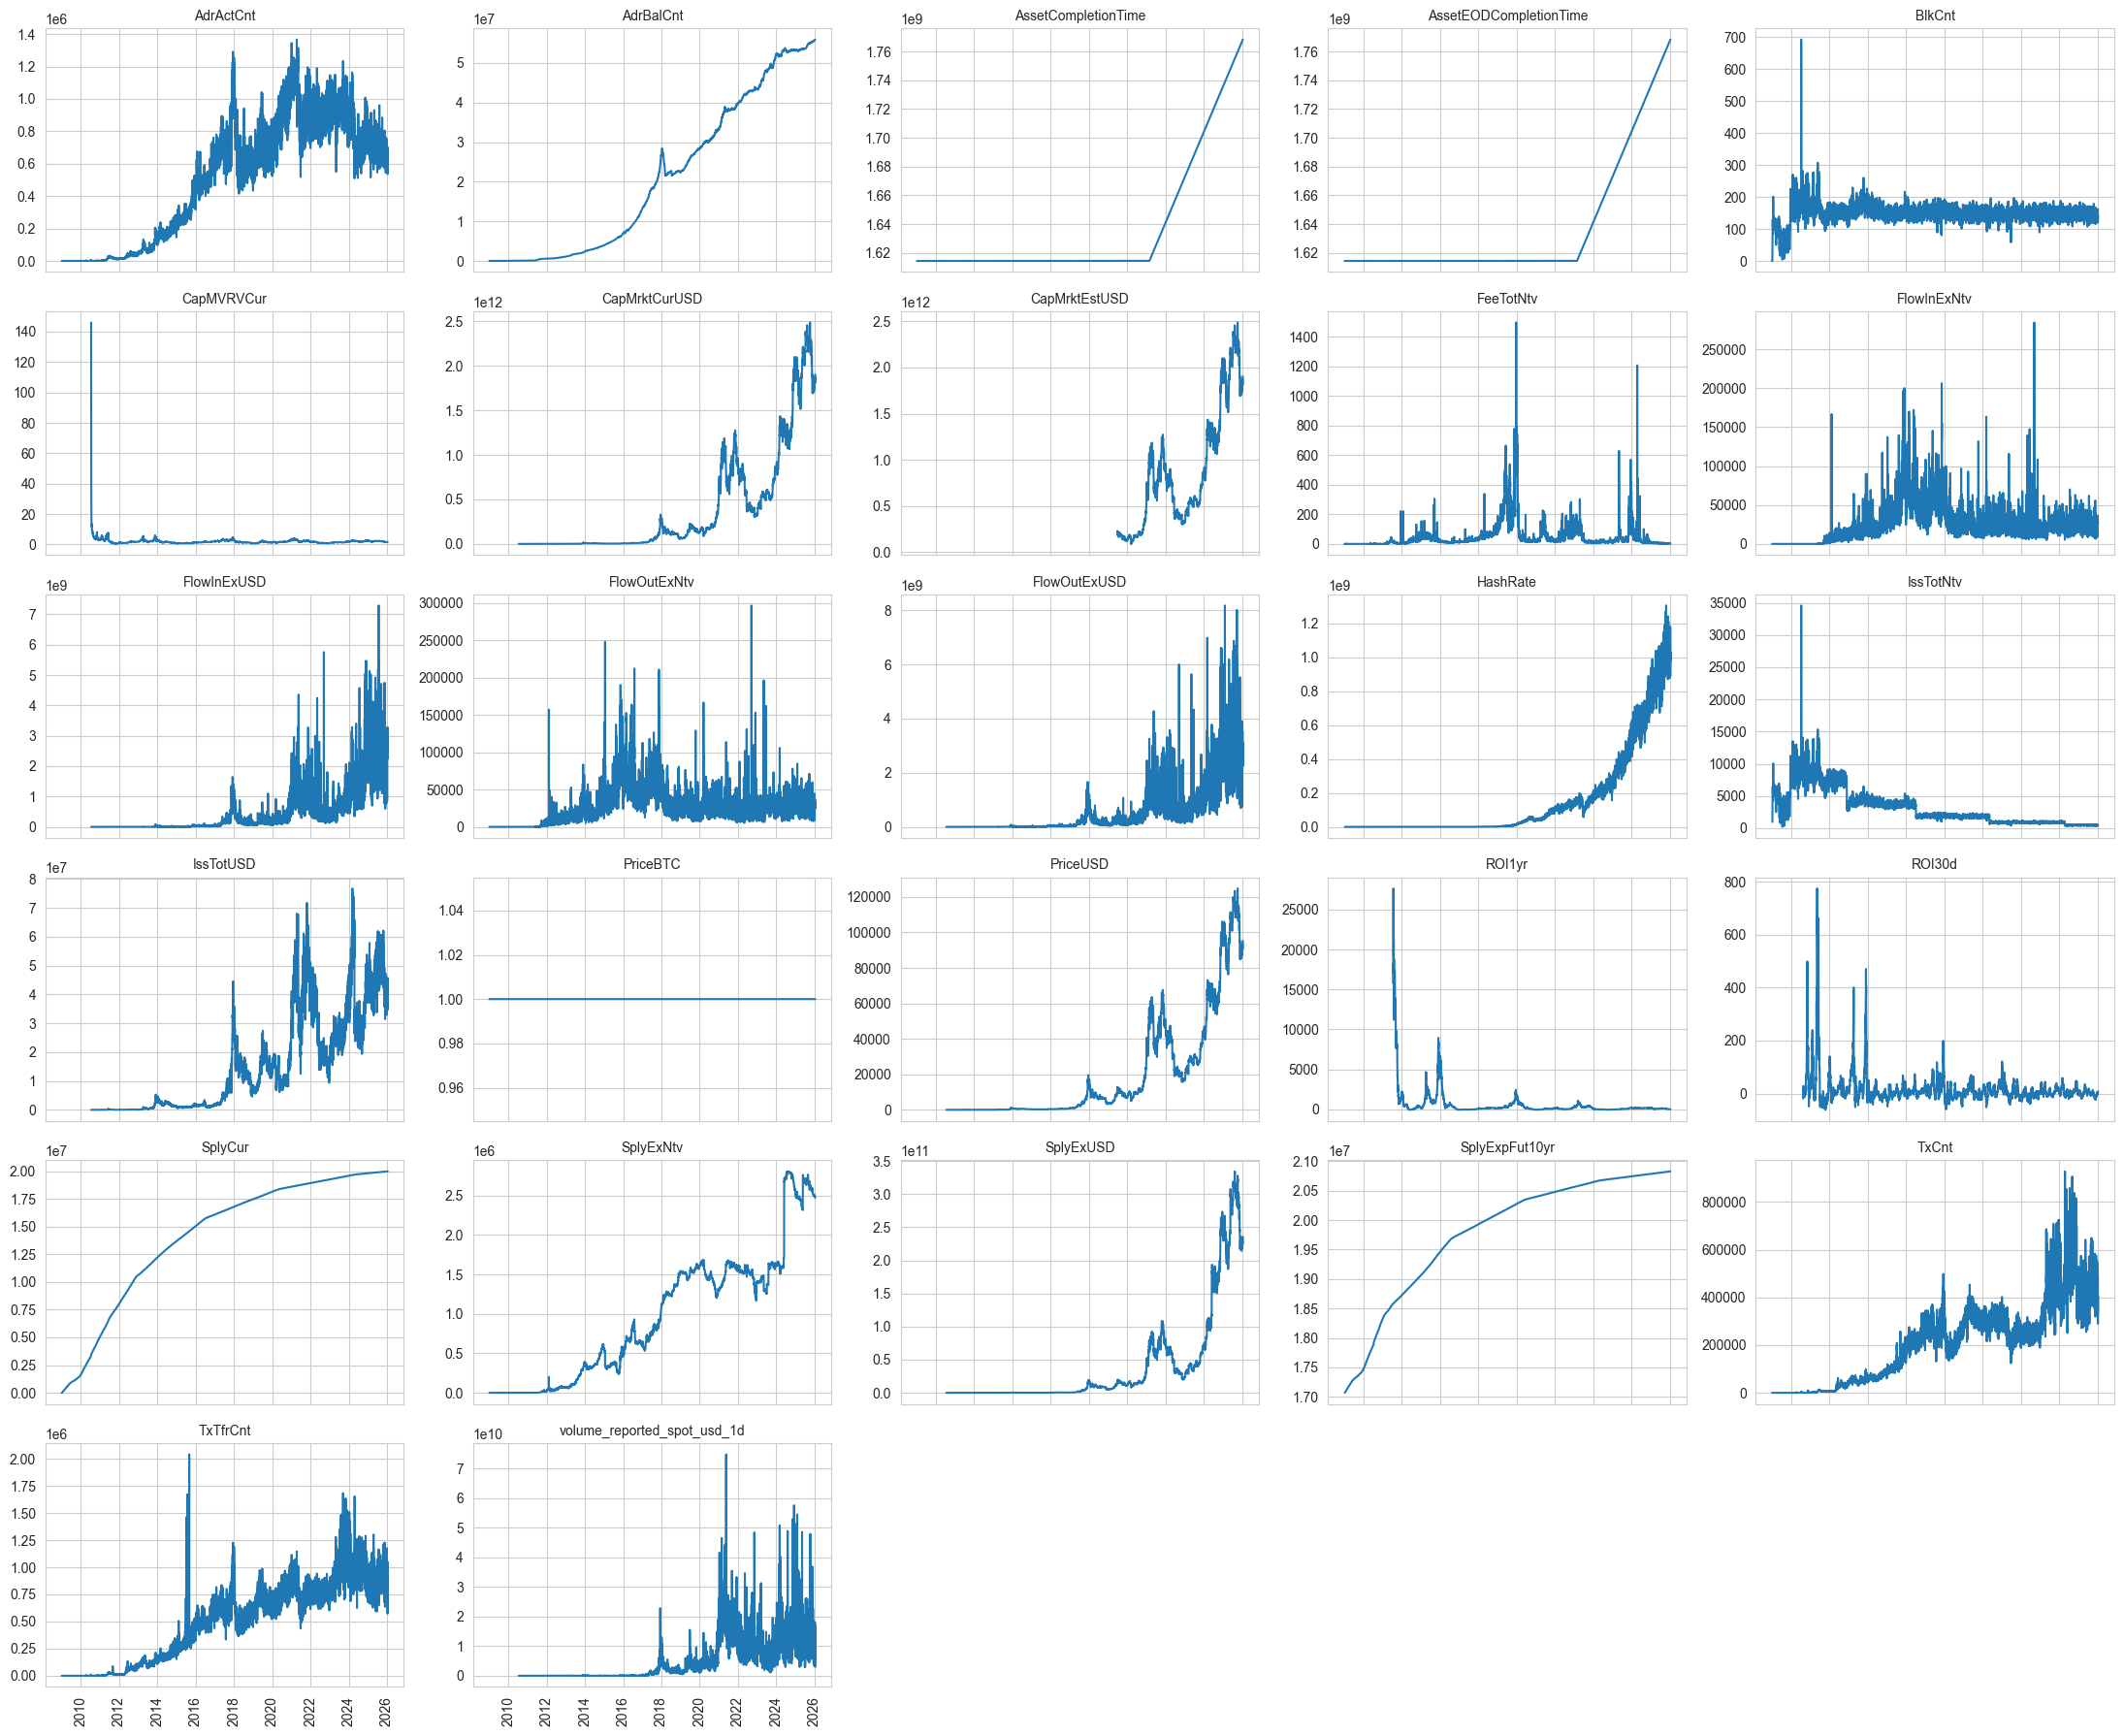

In [101]:
btc_pd = btc_df.to_pandas()
btc_pd["time"] = pd.to_datetime(btc_pd["time"], errors="coerce")
btc_pd = btc_pd.sort_values("time")
cols = [c for c in btc_pd.columns if c not in ["time","ReferenceRateUSD", "ReferenceRateEUR", "ReferenceRateETH", "ReferenceRate"]]
nrows, ncols = 6, 5
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 18), sharex=True)
axes = axes.ravel()
for i, col in enumerate(cols):
    ax = axes[i]
    ax.plot(btc_pd["time"], btc_pd[col])
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis="x", labelrotation=90)
for j in range(len(cols), nrows * ncols):
    axes[j].axis("off")

fig.tight_layout()
plt.show()

### 3.2 Polymarket data overview

In [5]:
# Overview of the polymarket data summary
eda.analyze_polymarket_summary(poly_data)


--- Polymarket Data Summary ---
Total Markets: 78321
Active Markets: 78321
Closed Markets: 0
Total Volume: $18,203,500,864.53
Average Volume per Market: $232,421.71
Total Tokens: 156636
shape: (5, 3)
┌───────────┬─────────────────────────────────┬─────────┐
│ market_id ┆ token_id                        ┆ outcome │
│ ---       ┆ ---                             ┆ ---     │
│ str       ┆ str                             ┆ str     │
╞═══════════╪═════════════════════════════════╪═════════╡
│ 240383    ┆ 555875344331027638590324435858… ┆ Yes     │
│ 240383    ┆ 111837615529992437689409005124… ┆ No      │
│ 240384    ┆ 113459643164060403919504712048… ┆ Yes     │
│ 240384    ┆ 110606609354376812966157988257… ┆ No      │
│ 240385    ┆ 505435736314143687770680977181… ┆ Yes     │
└───────────┴─────────────────────────────────┴─────────┘
Total Trades: 27013724
shape: (5, 9)
┌────────────┬───────────┬────────────┬────────────┬───┬────────────┬──────┬───────────┬───────────┐
│ trade_id   ┆ market_i

How much of it is related to Bitcoin/BTC?
* Some of the smaller categories are merged into larger ones and used as training data to categorize markets with missing category
* "Crypto" markets with questions containing "Bitcoin" or "BTC" are recategorized into separate category

In [6]:
markets_df = poly_data.get("markets")
markets_df_new = eda.categorize_markets(markets_df)

                    precision    recall  f1-score   support

          Business      0.750     0.913     0.824        23
            Crypto      0.986     1.000     0.993        68
   Global Politics      0.750     0.400     0.522        15
             Other      1.000     0.500     0.667         2
US-current-affairs      0.927     0.962     0.944        53

          accuracy                          0.913       161
         macro avg      0.883     0.755     0.790       161
      weighted avg      0.911     0.913     0.905       161



As a start, we can use ~26% of the *market* dataset for the Bitcoin accumulation strategy development

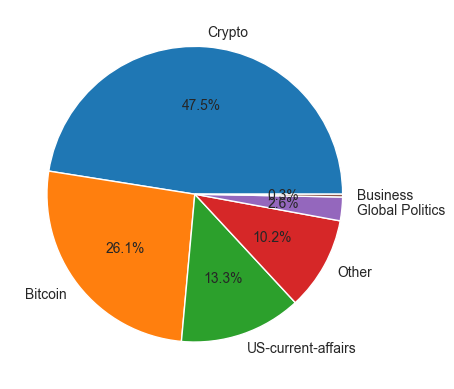

In [7]:
total = markets_df_new.height
top_cats = (
    markets_df_new.group_by("category")
    .agg(pl.count("market_id").alias("count"))
    .with_columns(
        (pl.col("count") / total * 100).alias("pct")
    )
    .sort("count", descending=True)
)
fig, ax = plt.subplots()
ax.pie(top_cats["count"], labels=top_cats["category"], autopct='%1.1f%%')
plt.show()

## 4. Prediction Market Exploration

### 4.1 Feature engineering

**Bitcoin dataset**

New features are created for Bitcoin dataset for model training:
* lag_xd = future PriceUSD x days in the future
* delta_xd = price change x days in the future
* change_xd = delta_xd / PriceUSD - 1

In [8]:
btc_df = eda.btc_features(btc_df)

Daily price change is about equal but long-tailed for longer periods such as 7 days and 30 days. If possible, we should aim to look for signals where we can benefit from this asymmetric distribution.

<function matplotlib.pyplot.show(close=None, block=None)>

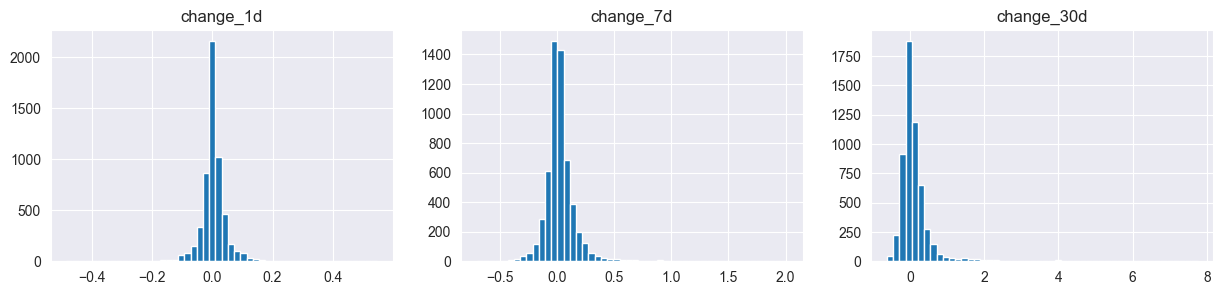

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3), sharex=False)
axes[0].hist(btc_df["change_1d"],bins=50)
axes[0].set_title("change_1d")
axes[1].hist(btc_df["change_7d"],bins=50)
axes[1].set_title("change_7d")
axes[2].hist(btc_df["change_30d"],bins=50)
axes[2].set_title("change_30d")
plt.show

**Polymarket dataset**

For Bitcoin Polymarket markets dataset, the "question" column can be categorized as:
* Bullish (value: +1) if the positive answer indicates price increase (e.g. "Will BTC hit $40,000 by Halloween?", "Bitcoin all time high in Q1?")
* Bearish (value: -1) if the positive answer indicates price decrease (e.g. "BTC dips below 65k before August?")
* Neutral (value: 0) if the question does not explicitly indicate price increase/decrease (e.g. "MOG vs. BITCOIN - Most Liked Post Today", "Will RFK Jr. say "Crypto" or "Bitcoin" during Friday address?")

Initial 600 rows with validated results are used to train model to categorize the rest with high accuracy. About 70% of the questions are framed as bullish

In [10]:
markets_df_bitcoin_new = eda.categorize_market_sentiment(markets_df_new.filter(pl.col("category")=="Bitcoin"))

              precision    recall  f1-score   support

     bearish      1.000     1.000     1.000        14
     bullish      0.975     0.975     0.975        79
     neutral      0.926     0.926     0.926        27

    accuracy                          0.967       120
   macro avg      0.967     0.967     0.967       120
weighted avg      0.967     0.967     0.967       120



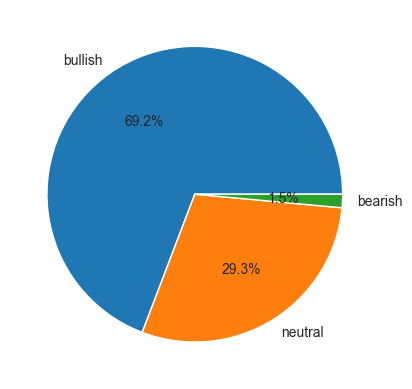

In [11]:
market_stance_cat = (
    markets_df_bitcoin_new.group_by("stance")
    .agg(pl.col("market_id").count().alias("count"))
    .sort("count", descending=True)
)

fig, ax = plt.subplots()
ax.pie(market_stance_cat["count"], labels=market_stance_cat["stance"], autopct='%1.1f%%')
plt.show()

The *tokens* dataset lists all possible answers for each market. We can categorize the answers to positive or negative. Depending on the question, the trade to "BUY" a token can be bullish, bearish, or neutral.

Subsequent code maps back the tokens interpretation for bullish/bearish/neutral trades and performs daily aggregation of the *trades* dataset, whether the sentiment is more bullish or bearish for bitcoin.

In [57]:
tokens_df = poly_data.get("tokens")
tokens_df = tokens_df.join(markets_df_bitcoin_new["market_id","question","stance","stance_val"], on="market_id", how="left",)
tokens_df_bitcoin = tokens_df.filter(pl.col("question").is_not_null())
tokens_df_bitcoin = eda.categorize_token_sentiment(tokens_df_bitcoin)

trades_df = poly_data.get("trades")
trades_df_bitcoin = eda.merge_tokens_trades(tokens_df_bitcoin, trades_df)

trades_df_bitcoin_day = eda.trades_daily_agg(trades_df_bitcoin)

The daily sentiment is bounded from -1 (Bitcoin doomsday) to 1 (euphoria) and can hopefully be integrated as a signal for accumulation.

<function matplotlib.pyplot.show(close=None, block=None)>

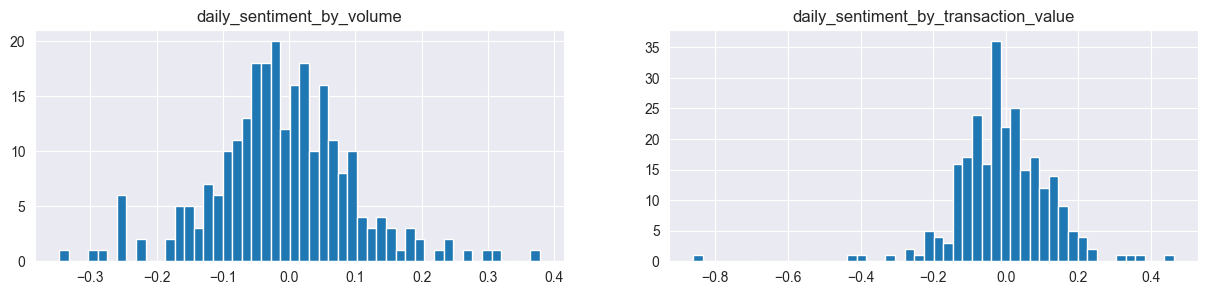

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 3), sharex=False)
axes[0].hist(trades_df_bitcoin_day["daily_sentiment_by_volume"],bins=50)
axes[0].set_title("daily_sentiment_by_volume")
axes[1].hist(trades_df_bitcoin_day["daily_sentiment_by_transaction_value"],bins=50)
axes[1].set_title("daily_sentiment_by_transaction_value")
plt.show

### 4.2 Correlation and significance study

Pure correlation study only shows fairly weak signals or metrics which are not suitable from Bitcoin on-chain/macro dataset. Further enhancement is needed.

In [33]:
corr_df = btc_df.to_pandas()
corr = corr_df.corr().iloc[:32,] # Exclude engineered features on row

In [50]:
s = corr["change_7d"]
print(pd.concat([
    s.sort_values().head(3),
    s.sort_values(ascending=False).head(3)
]))
print("===============================")
s = corr["change_30d"]
print(pd.concat([
    s.sort_values().head(3),
    s.sort_values(ascending=False).head(3)
]))

SplyCur          -0.160365
SplyExpFut10yr   -0.160186
time             -0.135753
ROI30d            0.213619
IssTotNtv         0.155196
BlkCnt            0.134281
Name: change_7d, dtype: float64
SplyCur          -0.276842
SplyExpFut10yr   -0.274063
time             -0.227829
IssTotNtv         0.259970
ROI30d            0.238563
BlkCnt            0.201365
Name: change_30d, dtype: float64


Similarly, polymarket data also does not show strong correlations. There is a moderate negative correlation between daily_volume and daily_transaction_value to change_30d, but further validation is needed.

In [58]:
right_df = btc_df[["time","PriceUSD","change_7d","change_30d"]].with_columns(pl.col("time").cast(pl.Date))
trades_df_bitcoin_day=trades_df_bitcoin_day.join(right_df, on="time", how="left")
corr2_df = trades_df_bitcoin_day.to_pandas()
corr2 = corr2_df.corr().iloc[:7,]

In [60]:
print(corr2["change_7d"].sort_values(ascending=False))
print("==================")
print(corr2["change_30d"].sort_values(ascending=False))

daily_netstance_transaction_value      -0.034825
daily_sentiment_by_transaction_value   -0.054314
daily_netstance_volume                 -0.059585
daily_sentiment_by_volume              -0.078844
daily_transaction_value                -0.248877
daily_volume                           -0.263046
time                                   -0.391601
Name: change_7d, dtype: float64
daily_netstance_transaction_value       0.012625
daily_sentiment_by_transaction_value   -0.030203
daily_netstance_volume                 -0.067755
daily_sentiment_by_volume              -0.083647
daily_volume                           -0.415913
daily_transaction_value                -0.438159
time                                   -0.688798
Name: change_30d, dtype: float64


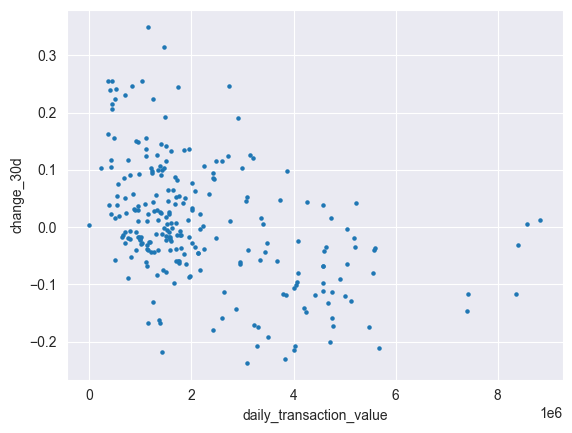

In [65]:
plt.scatter(trades_df_bitcoin_day["daily_transaction_value"],trades_df_bitcoin_day["change_30d"], marker="o", s=5)
plt.xlabel("daily_transaction_value")
plt.ylabel("change_30d")
plt.show()

XGBoost to search for most significant factors. Regression results are still extremely poor, but the SHAP values may give an indication of which columns to focus on in the next phase of the project.

In [97]:
X = btc_df.to_pandas().iloc[:,1:32]
y = btc_df.to_pandas()["change_7d"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, shuffle=False)
bst = XGBRegressor(n_estimators=200, max_depth=3)
bst.fit(X_train, y_train)
preds = bst.predict(X_test)

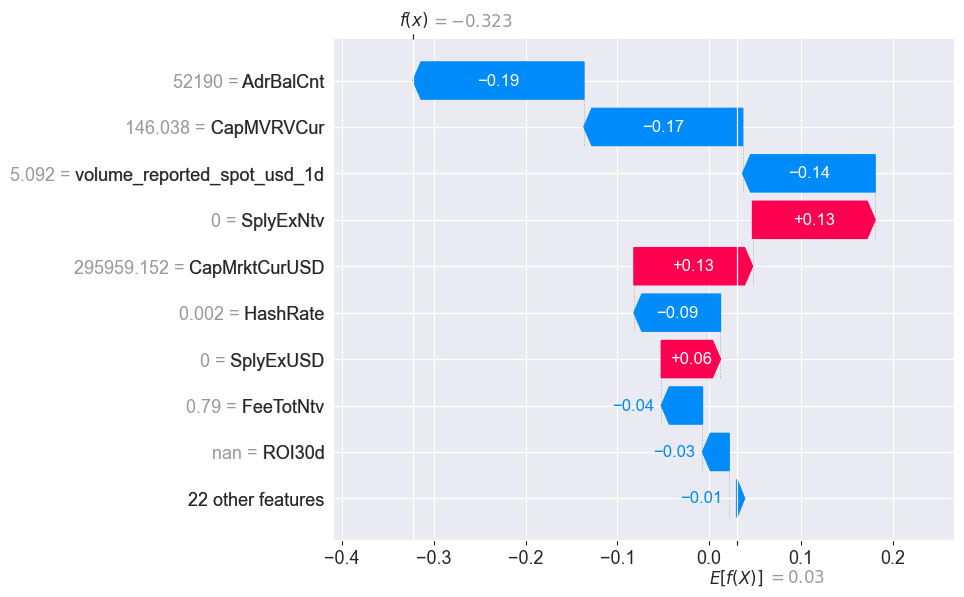

In [98]:
# Explain the model's predictions
explainer = shap.Explainer(bst)
shap_values = explainer(X)

# Visualize the first prediction
shap.plots.waterfall(shap_values[0])

### Next steps
* More rigorous feature engineering including technical indicators. Explore other sources to enhance dataset, including stock market and news data
* Explore other statistical tests to determine whether signal is significant
* Identify different regimes and understand characteristics of each
* Combine on-chain, macro, and polymarket data to get best accumulation signal and start training the model! To consider traditional ML, RL, Dyna-Q
